Analysis of Global Sales Trends and Product Seasonality
This notebook analyzes sales data across different regions and product categories to identify growth patterns, profitability, and seasonal fluctuations.

In [94]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

countries = pd.read_csv(r"C:\Users\Asus\Downloads\dataset\13. Final project\countries.csv",sep=',')
events = pd.read_csv(r"C:\Users\Asus\Downloads\dataset\13. Final project\events.csv", sep = ',')
products = pd.read_csv(r"C:\Users\Asus\Downloads\dataset\13. Final project\products.csv", sep= ',')
'''from google.colab import drive
drive.mount('/content/drive')

path = '/content/drive/MyDrive/practise/'

countries = pd.read_csv(path + 'countries.csv',sep=',')
events = pd.read_csv(path + 'events.csv',sep=',')
products = pd.read_csv(path + 'products.csv',sep=',')'''

for df in [countries, events, products]:
    df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

import pandas as  pd

print(countries.head())
print(events.head())

event_country_join = pd.merge(events, countries, left_on="country_code", right_on="alpha-3",how='left')

merged_df = pd.merge(event_country_join, products, left_on='product_id', right_on='id', how='left')

merged_df = merged_df.drop_duplicates()

cols_to_drop = ['id', 'alpha-2']
merged_df.drop(columns=cols_to_drop, inplace=True)

merged_df.rename(columns={'name': 'country_name'}, inplace=True)

print(merged_df)

             name alpha-2 alpha-3   region       sub-region
0     Afghanistan      AF     AFG     Asia    Southern Asia
1   Åland Islands      AX     ALA   Europe  Northern Europe
2         Albania      AL     ALB   Europe  Southern Europe
3         Algeria      DZ     DZA   Africa  Northern Africa
4  American Samoa      AS     ASM  Oceania        Polynesia
    order_id order_date   ship_date order_priority country_code  product_id  \
0  100640618  10/8/2014  10/18/2014              M          NOR        2103   
1  100983083  8/11/2016   8/11/2016              C          SRB        2103   
2  101025998  7/18/2014   8/11/2014              M          NaN        7940   
3  102230632  5/13/2017   6/13/2017              L          MNE        2455   
4  103435266  8/11/2012   9/18/2012              H          SRB        1270   

  sales_channel  units_sold  unit_price  unit_cost  
0        Online       650.0      205.70     117.11  
1       Offline      1993.0      205.70     117.11  
2     

In [95]:
merged_df.describe()


,order_id,product_id,units_sold,unit_price,unit_cost
count,1.330000e+03,1330.000000,1328.000000,1330.000000,1330.000000
mean,5.412048e+08,5788.096241,4952.201807,264.893541,187.246812
std,2.573882e+08,2820.728878,2905.198996,217.323460,176.158873
min,1.006406e+08,1270.000000,2.000000,9.330000,6.920000
25%,3.190004e+08,3127.000000,2356.750000,81.730000,35.840000
50%,5.387164e+08,5988.000000,4962.000000,154.060000,97.440000
75%,7.544628e+08,8681.000000,7459.500000,437.200000,263.330000
max,9.998797e+08,8969.000000,9999.000000,668.270000,524.960000


In [96]:
print(merged_df.shape)
merged_df.info()


(1330, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        1330 non-null   int64  
 1   order_date      1330 non-null   object 
 2   ship_date       1330 non-null   object 
 3   order_priority  1330 non-null   object 
 4   country_code    1248 non-null   object 
 5   product_id      1330 non-null   int64  
 6   sales_channel   1330 non-null   object 
 7   units_sold      1328 non-null   float64
 8   unit_price      1330 non-null   float64
 9   unit_cost       1330 non-null   float64
 10  country_name    1248 non-null   object 
 11  alpha-3         1248 non-null   object 
 12  region          1248 non-null   object 
 13  sub-region      1248 non-null   object 
 14  item_type       1330 non-null   object 
dtypes: float64(3), int64(2), object(10)
memory usage: 156.0+ KB


In [97]:
print(merged_df.isna().sum())
print(merged_df.isna().sum() / merged_df.shape[0] * 100)

order_id           0
order_date         0
ship_date          0
order_priority     0
country_code      82
product_id         0
sales_channel      0
units_sold         2
unit_price         0
unit_cost          0
country_name      82
alpha-3           82
region            82
sub-region        82
item_type          0
dtype: int64
order_id          0.000000
order_date        0.000000
ship_date         0.000000
order_priority    0.000000
country_code      6.165414
product_id        0.000000
sales_channel     0.000000
units_sold        0.150376
unit_price        0.000000
unit_cost         0.000000
country_name      6.165414
alpha-3           6.165414
region            6.165414
sub-region        6.165414
item_type         0.000000
dtype: float64


In [98]:
merged_df.dropna(subset=['country_code'], inplace=True)
merged_df.dropna(subset=['units_sold'], inplace=True)
print(merged_df.isna().sum())
print(merged_df.isna().sum() / merged_df.shape[0] * 100)

order_id          0
order_date        0
ship_date         0
order_priority    0
country_code      0
product_id        0
sales_channel     0
units_sold        0
unit_price        0
unit_cost         0
country_name      0
alpha-3           0
region            0
sub-region        0
item_type         0
dtype: int64
order_id          0.0
order_date        0.0
ship_date         0.0
order_priority    0.0
country_code      0.0
product_id        0.0
sales_channel     0.0
units_sold        0.0
unit_price        0.0
unit_cost         0.0
country_name      0.0
alpha-3           0.0
region            0.0
sub-region        0.0
item_type         0.0
dtype: float64


In [99]:
merged_df['order_date']=pd.to_datetime(merged_df['order_date'])
merged_df['ship_date']=pd.to_datetime(merged_df['ship_date'])
print(merged_df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 1246 entries, 0 to 1329
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        1246 non-null   int64         
 1   order_date      1246 non-null   datetime64[ns]
 2   ship_date       1246 non-null   datetime64[ns]
 3   order_priority  1246 non-null   object        
 4   country_code    1246 non-null   object        
 5   product_id      1246 non-null   int64         
 6   sales_channel   1246 non-null   object        
 7   units_sold      1246 non-null   float64       
 8   unit_price      1246 non-null   float64       
 9   unit_cost       1246 non-null   float64       
 10  country_name    1246 non-null   object        
 11  alpha-3         1246 non-null   object        
 12  region          1246 non-null   object        
 13  sub-region      1246 non-null   object        
 14  item_type       1246 non-null   object        
dtypes: dateti

In [100]:

duplicate_rows = merged_df.duplicated()
print(duplicate_rows)
print(duplicate_rows.sum())

0       False
1       False
3       False
4       False
5       False
        ...  
1325    False
1326    False
1327    False
1328    False
1329    False
Length: 1246, dtype: bool
0


In [101]:
print(merged_df.describe())
#anomalies in a dataset are abscent
# аномалії відсуні


           order_id                     order_date  \
count  1.246000e+03                           1246   
mean   5.432231e+08  2013-10-11 14:45:15.890850816   
min    1.006406e+08            2010-01-01 00:00:00   
25%    3.237987e+08            2011-12-09 18:00:00   
50%    5.438407e+08            2013-10-14 00:00:00   
75%    7.539619e+08            2015-09-01 12:00:00   
max    9.998797e+08            2017-07-22 00:00:00   
std    2.573524e+08                            NaN   

                           ship_date   product_id   units_sold   unit_price  \
count                           1246  1246.000000  1246.000000  1246.000000   
mean   2013-11-05 11:46:07.897271296  5756.146067  4953.186998   264.203387   
min              2010-01-10 00:00:00  1270.000000     2.000000     9.330000   
25%              2011-12-31 12:00:00  2455.000000  2349.250000    81.730000   
50%              2013-11-03 00:00:00  5988.000000  4980.000000   154.060000   
75%              2015-10-07 18:00:00  8

In [102]:
negative_margin = merged_df[merged_df['unit_price'] < merged_df['unit_cost']]
print(len(negative_margin))
# negative margin is abscent
# негативна  маржа відсутня


0


In [103]:
merged_df['order_priority'] = merged_df['order_priority'].str.strip().str.upper()

In [104]:
print(merged_df.info)

<bound method DataFrame.info of        order_id order_date  ship_date order_priority country_code  product_id  \
0     100640618 2014-10-08 2014-10-18              M          NOR        2103   
1     100983083 2016-08-11 2016-08-11              C          SRB        2103   
3     102230632 2017-05-13 2017-06-13              L          MNE        2455   
4     103435266 2012-08-11 2012-09-18              H          SRB        1270   
5     103450715 2015-03-15 2015-04-18              H          SVK        8681   
...         ...        ...        ...            ...          ...         ...   
1325  994504153 2017-01-10 2017-01-13              M          SWE        4594   
1326  994978797 2014-12-05 2015-01-02              H          ITA        1270   
1327  996754205 2010-09-20 2010-09-22              L          RUS        7331   
1328  998043382 2010-06-15 2010-07-03              H          MLT        8293   
1329  999879729 2012-03-31 2012-05-06              M          ALB        7940

### KPI Summary

In [105]:

merged_df['revenue'] = merged_df['unit_price'] * merged_df['units_sold']
merged_df['profit'] = (merged_df['unit_price'] - merged_df['unit_cost']) * merged_df['units_sold']

#totals
total_revenue = round(merged_df['revenue'].sum())
total_profit = merged_df['profit'].sum()
total_orders = len(merged_df)
total_units_sold = merged_df['units_sold'].sum()

# 3. Efficiency Metrics
avg_order_revenue = total_revenue / total_orders
overall_profit_margin = (total_profit / total_revenue) * 100
total_countries = merged_df['country_name'].nunique()
avg_units_per_order = int(round(total_units_sold / total_orders))

# --- Display Formatted KPIs ---
display(Markdown("### KPI Summary:"))
display(Markdown(f"* **Total Revenue:** `${total_revenue:,.0f}`"))
display(Markdown(f"* **Total Profit:** `${total_profit:,.0f}`"))
display(Markdown(f"* **Total Orders:** `{total_orders:,}`"))
display(Markdown(f"* **Average Order Value (AOV):** `${avg_order_revenue:,.2f}`"))
display(Markdown(f"* **Overall Profit Margin:** `{overall_profit_margin:.2f}%`"))
display(Markdown(f"* **Average Units per Order:** `{avg_units_per_order:} units`"))
display(Markdown(f"* **Countries Captured:** `{total_countries}`"))

### KPI Summary:

* **Total Revenue:** `$1,598,983,761`

* **Total Profit:** `$473,709,035`

* **Total Orders:** `1,246`

* **Average Order Value (AOV):** `$1,283,293.55`

* **Overall Profit Margin:** `29.63%`

* **Average Units per Order:** `4953 units`

* **Countries Captured:** `45`

### Temporal & Trend Analysis (Over Time)

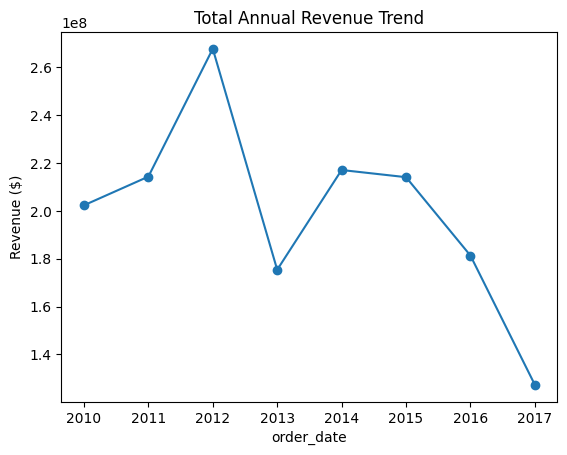

In [106]:
#annual revenue

annual_revenue = merged_df.resample('YE', on='order_date')['revenue'].sum()
annual_revenue.index = annual_revenue.index.year

annual_revenue.plot(kind='line', marker='o', title='Total Annual Revenue Trend')
plt.ylabel('Revenue ($)')
plt.savefig('annual_revenue.png')



,YoY Growth %
order_date,
2011,+5.91%
2012,+24.90%
2013,-34.46%
2014,+23.73%
2015,-1.38%
2016,-15.29%
2017,-29.74%


C:\Users\Asus\AppData\Local\Temp\ipykernel_22488\626866905.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=revenue_growth.index, y=revenue_growth.values, palette='coolwarm')


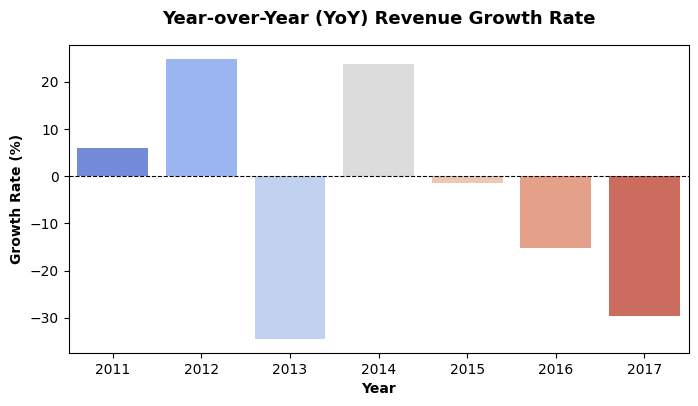

In [ ]:
# percentage  difference between revenue through years

revenue_growth = (annual_revenue.pct_change() * 100).dropna()

display(revenue_growth.to_frame(name='YoY Growth %').style.format("{:+.2f}%"))

plt.figure(figsize=(8, 4))

sns.barplot(x=revenue_growth.index, y=revenue_growth.values, palette='coolwarm')

plt.axhline(0, color='black', linewidth=0.8, linestyle='--') # Highlights positive vs negative growth
plt.title("Year-over-Year (YoY) Revenue Growth Rate", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Year", fontweight='bold')
plt.ylabel("Growth Rate (%)", fontweight='bold')

,Total Profit
order_date,
2010,"$59,817,992.71"
2011,"$64,367,010.94"
2012,"$83,070,056.18"
2013,"$51,221,929.68"
2014,"$65,979,379.16"
2015,"$58,226,509.54"
2016,"$55,100,085.19"
2017,"$35,926,071.66"


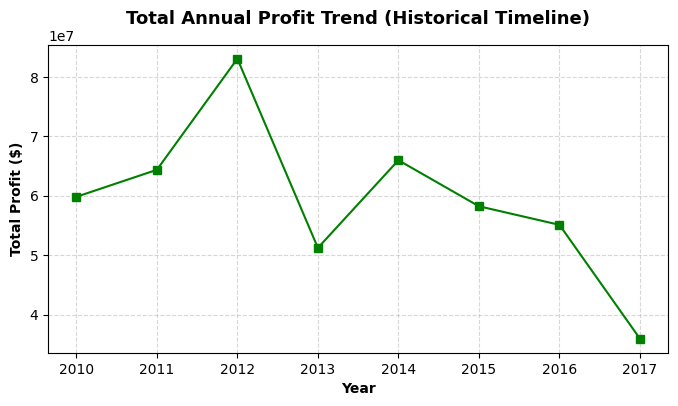

In [ ]:
#profit through time

annual_profit = merged_df.resample('YE', on='order_date')['profit'].sum()
annual_profit.index = annual_profit.index.year

display(annual_profit.to_frame(name='Total Profit').style.format("${:,.2f}"))

fig, ax = plt.subplots(figsize=(8, 4))
annual_profit.plot(kind='line', marker='s', color='green', ax=ax)

ax.set_title('Total Annual Profit Trend (Historical Timeline)', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontweight='bold')
ax.set_ylabel('Total Profit ($)', fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.5)



,YoY Profit Growth %
order_date,
2011,+7.60%
2012,+29.06%
2013,-38.34%
2014,+28.81%
2015,-11.75%
2016,-5.37%
2017,-34.80%


C:\Users\Asus\AppData\Local\Temp\ipykernel_22488\1870100300.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=profit_growth.index, y=profit_growth.values, palette='coolwarm', ax=ax)


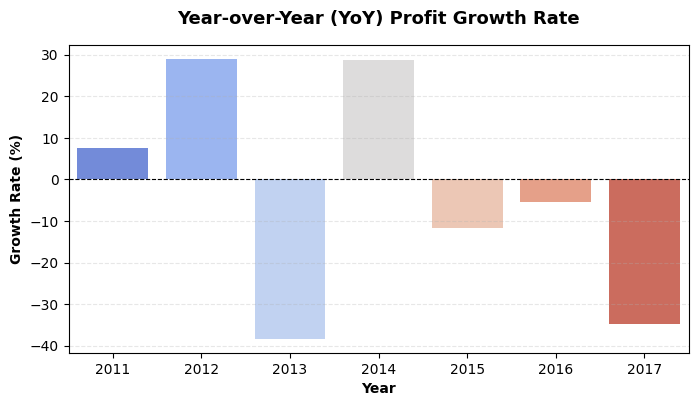

In [ ]:
# percentage  difference between profit through years


annual_profit = merged_df.resample('YE', on='order_date')['profit'].sum()
annual_profit.index = annual_profit.index.year

# Calculating percentage change and drop the first year's nan value
profit_growth = (annual_profit.pct_change() * 100).dropna()

display(profit_growth.to_frame(name='YoY Profit Growth %').style.format("{:+.2f}%"))

fig, ax = plt.subplots(figsize=(8, 4))

sns.barplot(x=profit_growth.index, y=profit_growth.values, palette='coolwarm', ax=ax)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--') 
ax.set_title("Year-over-Year (YoY) Profit Growth Rate", fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel("Year", fontweight='bold')
ax.set_ylabel("Growth Rate (%)", fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.3, axis='y')


,Total Orders
order_date,
2010,159
2011,163
2012,187
2013,150
2014,172
2015,150
2016,165
2017,100


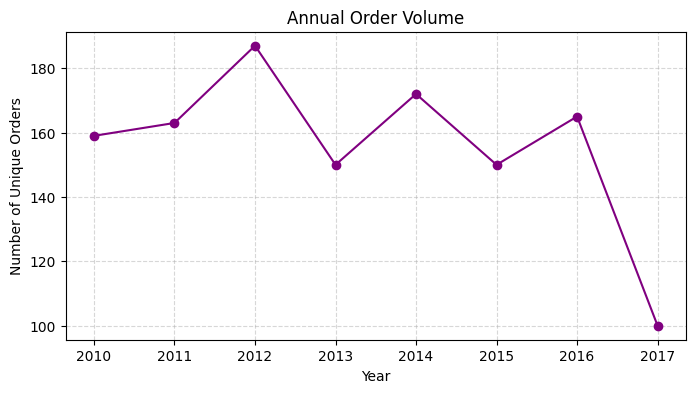

In [128]:

# Annual Order Volume
annual_orders = merged_df.resample('YE', on='order_date')['order_id'].nunique()
annual_orders.index = annual_orders.index.year

display(annual_orders.to_frame(name='Total Orders'))

annual_orders.plot(kind='line', marker='o', color='purple', title='Annual Order Volume', figsize=(8, 4))
plt.xlabel('Year')
plt.ylabel('Number of Unique Orders')
plt.grid(True, linestyle='--', alpha=0.5)


## Conclusions

* **Growth Phase (2011–2012):** The business reached its strongest performance in 2012, driven by a +24.90% increase in revenue and a +29.06% rise in net profit. This period reflects strong operational leverage, where scaling wholesale activity was accompanied by sustained margin strength.

* **Long-Term Contraction (2015–2017):** After 2014, the business entered a sustained downturn in revenue, ending with a significant -29.74% decline in 2017. This marks a clear structural shift from expansion to contraction.

* **Demand-Led Decline:** Trends in annual order volume closely align with the financial downturn, indicating that reduced transaction activity is likely the primary driver of revenue contraction. While unit economics appear relatively stable, overall performance weakened due to a lower number of transactions rather than an isolated pricing deterioration.

* **2015 Margin Compression:** In 2015, revenue remained relatively stable (-1.38%), while net profit declined more sharply (-11.75%). This divergence signals margin pressure, likely linked to higher procurement costs, increased COGS, or rising logistics and fulfillment expenses.

* **Structural Cost Exposure:** In contraction years such as 2013 and 2017, profit declined faster than revenue, suggesting the presence of relatively high fixed costs (e.g., warehousing, staffing, or supplier commitments). As volumes decreased, these fixed expenses were less effectively absorbed, reducing overall profitability.

* **Adaptive Cost Management in 2016:** Despite a -15.29% decline in revenue in 2016, net profit decreased by only -5.37%. This indicates effective cost containment and operational adjustments, potentially through expense reductions, improved procurement efficiency, or a shift toward a more favorable product mix that helped stabilize margins.



Geographical & Regional Performance

In [111]:
#Avg profit based on country 
check_c = round(merged_df.groupby('country_name')['profit'].mean().sort_values(ascending=False))

display(check_c.to_frame(name='Avg Profit'))


,Avg Profit
country_name,
Hungary,551449.0
Albania,499557.0
Malta,456566.0
Portugal,453816.0
Slovenia,449019.0
Ukraine,448634.0
Germany,445497.0
Czech Republic,439858.0
Croatia,430484.0


In [112]:
#orders revenue and  profit by countries

country_analysis = merged_df.groupby('country_name').agg({'order_id': 'nunique','revenue': 'sum', 'profit':'sum'})

country_analysis.columns = ['Total Orders', 'Total Revenue', 'Total Profit']

country_analysis = country_analysis.sort_values(by='Total Revenue', ascending=False)

display(country_analysis.style.format({'Total Revenue': "{:,.2f} $", 'Total Profit': "{:,.2f} $"}))

,Total Orders,Total Revenue,Total Profit
country_name,,,
Czech Republic,31,"53,543,932.14 $","13,635,593.78 $"
Ukraine,33,"53,252,317.54 $","14,804,925.74 $"
Bosnia and Herzegovina,33,"50,117,508.49 $","13,257,602.77 $"
Macedonia,32,"49,222,085.25 $","13,684,099.95 $"
San Marino,40,"47,883,708.48 $","13,792,992.81 $"
Andorra,40,"47,756,693.17 $","15,410,036.63 $"
Portugal,25,"47,172,189.84 $","11,345,407.59 $"
Malta,32,"47,145,320.81 $","14,610,127.88 $"
Russia,32,"46,051,659.81 $","13,267,682.64 $"


,Avg Days to Ship
region,
Europe,24.8
Asia,26.1


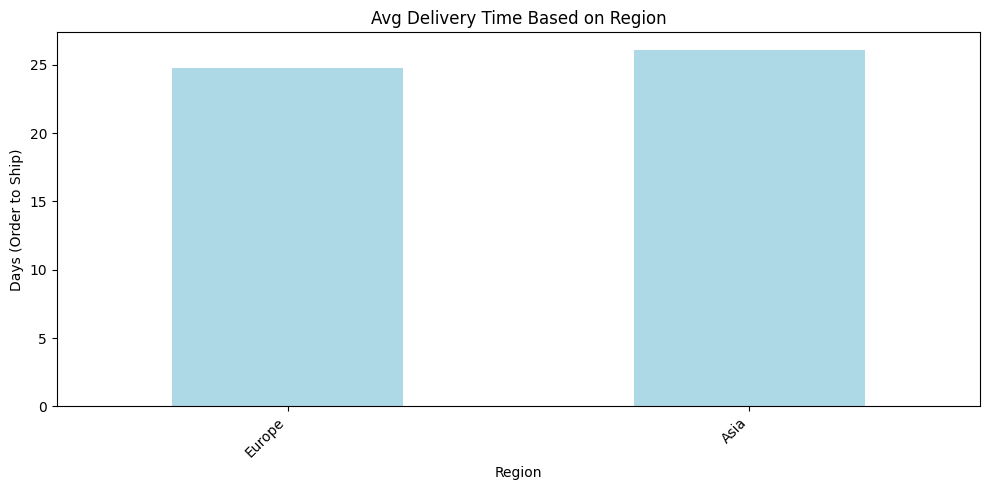

In [129]:
#Avg Delivery time based on region

merged_df['processing_time'] = (
    pd.to_datetime(merged_df['ship_date']) - pd.to_datetime(merged_df['order_date'])
).dt.days

check_r = merged_df.groupby('region')['processing_time'].mean().sort_values()

merged_df['processing_time'] = (pd.to_datetime(merged_df['ship_date']) - pd.to_datetime(merged_df['order_date'])).dt.days

display(check_r.round(1).to_frame(name='Avg Days to Ship'))

plt.figure(figsize=(10, 5))
check_r.plot(kind='bar', color='lightblue')
plt.title('Avg Delivery Time Based on Region')
plt.ylabel('Days (Order to Ship)')
plt.xlabel('Region')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [130]:

# Avg Profit per order based on Country
country_stats = merged_df.groupby('country_name').agg({'profit': 'sum', 'order_id': 'nunique'})

check_c = (country_stats['profit'] / country_stats['order_id']).sort_values(ascending=False)

display(round(check_c, 2).to_frame(name='Avg Profit per Order'))

,Avg Profit per Order
country_name,
Hungary,551449.24
Albania,499557.43
Malta,456566.50
Portugal,453816.30
Slovenia,449019.43
Ukraine,448634.11
Germany,445496.89
Czech Republic,439857.86
Croatia,430484.09


=== TOP 5 COUNTRIES BY REVENUE ===


,Total Revenue,Revenue Rank
country_name,,
Czech Republic,"$53,543,932.14",1
Ukraine,"$53,252,317.54",2
Bosnia and Herzegovina,"$50,117,508.49",3
Macedonia,"$49,222,085.25",4
San Marino,"$47,883,708.48",5



=== TOP 5 COUNTRIES BY PROFIT ===


,Total Profit,Profit Rank
country_name,,
Andorra,"$15,410,036.63",1
Ukraine,"$14,804,925.74",2
Malta,"$14,610,127.88",3
San Marino,"$13,792,992.81",4
Hungary,"$13,786,231.03",5


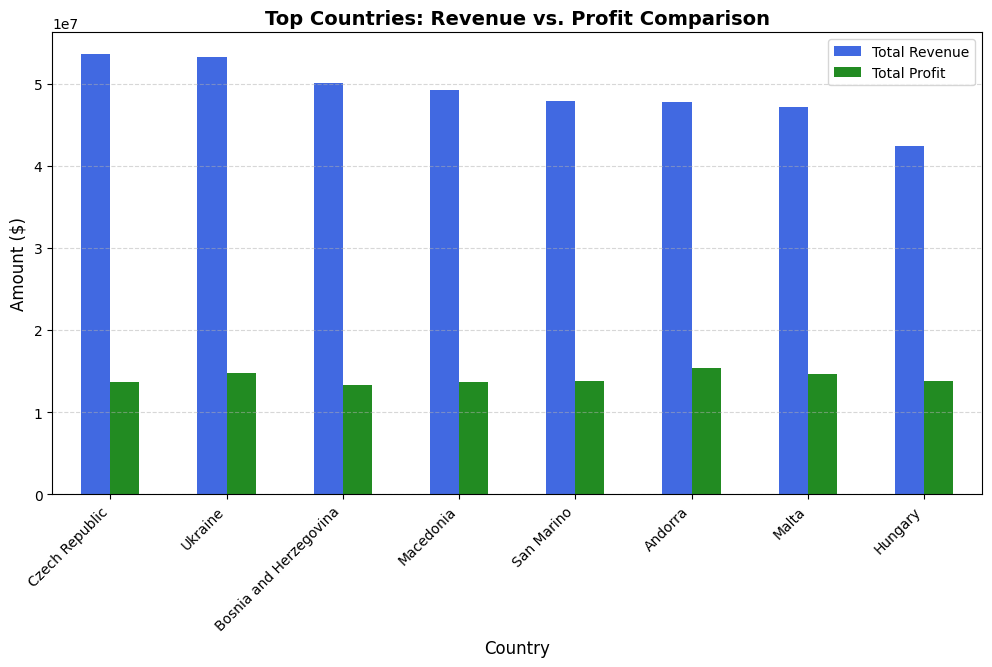

In [131]:
# top 5 countries by revenue 

country_totals = merged_df.groupby('country_name')[['revenue', 'profit']].sum()


top_5_revenue = country_totals['revenue'].nlargest(5).to_frame(name='Total Revenue')
top_5_revenue['Revenue Rank'] = range(1, 6)

top_5_profit = country_totals['profit'].nlargest(5).to_frame(name='Total Profit')
top_5_profit['Profit Rank'] = range(1, 6)

print("=== TOP 5 COUNTRIES BY REVENUE ===")
display(top_5_revenue.style.format({'Total Revenue': "${:,.2f}"}))

print("\n=== TOP 5 COUNTRIES BY PROFIT ===")
display(top_5_profit.style.format({'Total Profit': "${:,.2f}"}))


top_rev_countries = top_5_revenue.index
top_prof_countries = top_5_profit.index
top_combined = top_rev_countries.union(top_prof_countries)

comparison_df = country_totals.loc[top_combined].sort_values(by='revenue', ascending=False)


ax = comparison_df[['revenue', 'profit']].plot(kind='bar', figsize=(12, 6), color=['royalblue', 'forestgreen'])

ax.set_title('Top Countries: Revenue vs. Profit Comparison', fontsize=14, fontweight='bold')
ax.set_ylabel('Amount ($)', fontsize=12)
ax.set_xlabel('Country', fontsize=12)
ax.set_xticklabels(comparison_df.index, rotation=45, ha='right')
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.legend(['Total Revenue', 'Total Profit'])


#### Conclusion:
 Geographical & Regional Performance
The financial and operational analysis across regions reveals a critical divergence between Revenue and Profit. While Eastern and Southern European nations dominate total financial footprint, the strategies required to manage them differ significantly.

1. (High Volume & High Returns)
Ukraine and San Marino are the clear cornerstones of the geographical portfolio, with both markets ranking in the Top 5 for total revenue and net profit.

2. The High-Volume, Low-Margin Warning Zone
Czech Republic, Bosnia and Herzegovina, and North Macedonia are major contributors to overall revenue scale, with Czech Republic leading the global portfolio at $53.54M in revenue.

However, despite their substantial revenue generation, none of these markets ranked in the Top 5 for profitability. The gap highlighted in the comparison chart points to significant margin pressure

3. Andorra and Malta stand out as highly efficient, high-margin markets with strong pricing power and low operational overhead. They are attractive candidates for expansion, and can be considered as such after additional analysis of market size, scalability, and long-term demand would be necessary before classifying them as ideal expansion targets.

Product & Sales Channel Insights

### Logistics & Operational Efficiency

,total_orders,avg_days_to_ship,total_profit,avg_profit_per_order
region,,,,
Europe,1164,24.8 Days,"$448,556,782.11","$385,358.06"
Asia,82,26.1 Days,"$25,152,252.95","$306,734.79"


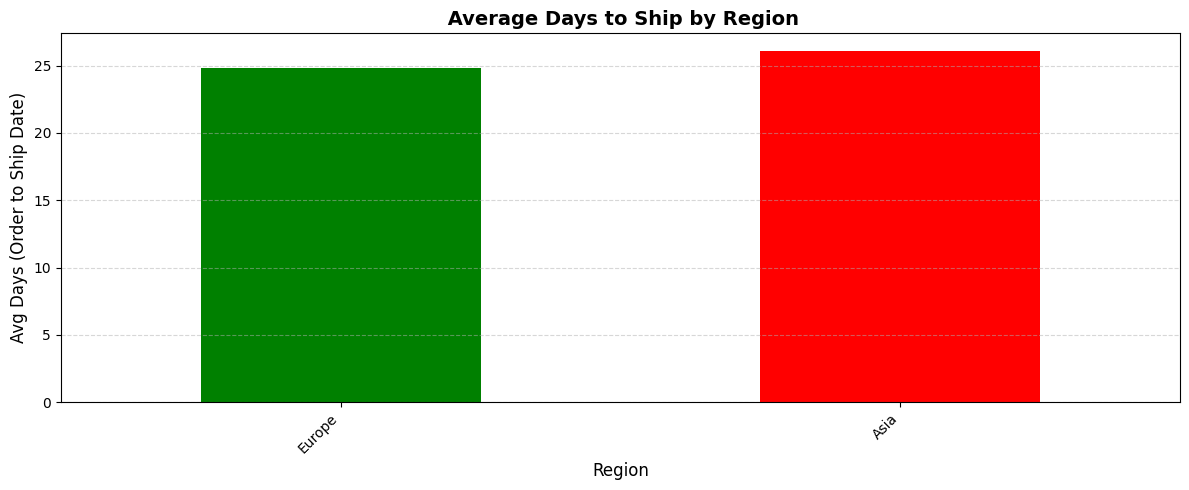

=== LOGISTICS CORRELATION MATRIX ===


,processing_time,revenue,profit
processing_time,1.000000,0.064909,0.060695
revenue,0.064909,1.000000,0.876077
profit,0.060695,0.876077,1.000000


no relationship between region and delivery time


In [ ]:
#Comparison of logistic efficiency between regions + its impact on prof


# Analyzing logistics and profit metrics together by region
region_logistics = merged_df.groupby('region').agg(
    total_orders=('order_id', 'count'),
    avg_days_to_ship=('processing_time', 'mean'),
    total_profit=('profit', 'sum')
).sort_values(by='avg_days_to_ship')

# Calculating avg profit generated per order in that region
region_logistics['avg_profit_per_order'] = region_logistics['total_profit'] / region_logistics['total_orders']

display(region_logistics.style.format({
    'avg_days_to_ship': "{:.1f} Days", 
    'total_profit': "${:,.2f}", 
    'avg_profit_per_order': "${:,.2f}"
}))


plt.figure(figsize=(12, 5))
colors = ['g' if x == region_logistics['avg_days_to_ship'].min() else 'r' if x == region_logistics['avg_days_to_ship'].max() else 'lightblue' for x in region_logistics['avg_days_to_ship']]

region_logistics['avg_days_to_ship'].plot(kind='bar', color=colors)
plt.title(' Average Days to Ship by Region', fontsize=14, fontweight='bold')
plt.ylabel('Avg Days (Order to Ship Date)', fontsize=12)
plt.xlabel('Region', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 2. correlation analysis to check relationship between logistics and finances
correlation_matrix = merged_df[['processing_time', 'revenue', 'profit']].corr()

print("=== LOGISTICS CORRELATION MATRIX ===")
display(correlation_matrix)

print( f'no relationship between region and delivery time')


,Avg Days to Ship
item_type,
Personal Care,20.0
Clothes,24.0
Household,24.0
Beverages,24.0
Vegetables,24.0
Fruits,24.0
Snacks,25.0
Meat,26.0
Cosmetics,26.0



=== ITEM TYPE & DELIVERY TIME STATISTICAL DEPENDENCY (ANOVA) ===
F-Statistic: 1.8503
P-Value: 0.041896

Conclusion:
 p< 0.05 SIGNIFICANT DEPENDENCY: Item type directly impacts processing time.


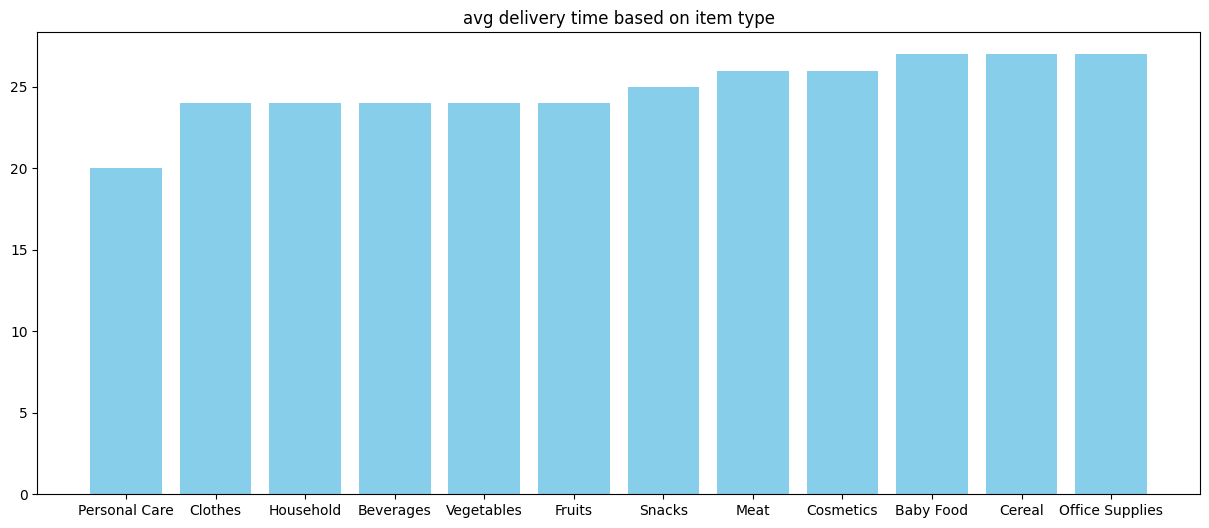

In [ ]:
#Avg Delivery time based on item type
import scipy.stats as stats
check_it = round(merged_df.groupby('item_type')['processing_time'].mean().sort_values(),0)
display(check_it.to_frame(name='Avg Days to Ship'))
plt.figure(figsize=(15, 6))
plt.bar(check_it.index, check_it.values, color='skyblue')


plt.title('avg delivery time based on item type')

item_groups = [group['processing_time'].values for name, group in merged_df.groupby('item_type')]
f_stat, p_val = stats.f_oneway(*item_groups)

print("\n=== ITEM TYPE & DELIVERY TIME STATISTICAL DEPENDENCY (ANOVA) ===")
print(f"F-Statistic: {f_stat:.4f}")
print(f"P-Value: {p_val:.6f}")


print("\nConclusion:")
if p_val < 0.05:
    print(" p< 0.05" \
    " SIGNIFICANT DEPENDENCY: Item type directly impacts processing time.")
else:
    print("❌ NO DEPENDENCY")
   

,Avg Days to Ship
order_priority,
C,24.0
H,24.0
L,25.0
M,26.0


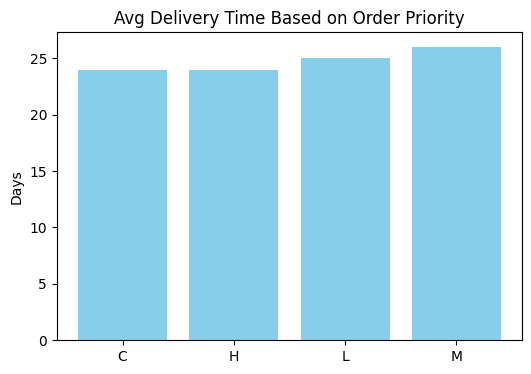

In [ ]:
#Avg  Delivery  Time  based on Order Priority
priority_check = round(merged_df.groupby('order_priority')['processing_time'].mean().sort_values(), 0)
display(priority_check.to_frame(name='Avg Days to Ship'))

plt.figure(figsize=(6, 4)) 
plt.bar(priority_check.index, priority_check.values, color='skyblue')
plt.title('Avg Delivery Time Based on Order Priority')
plt.ylabel('Days')
plt.show()

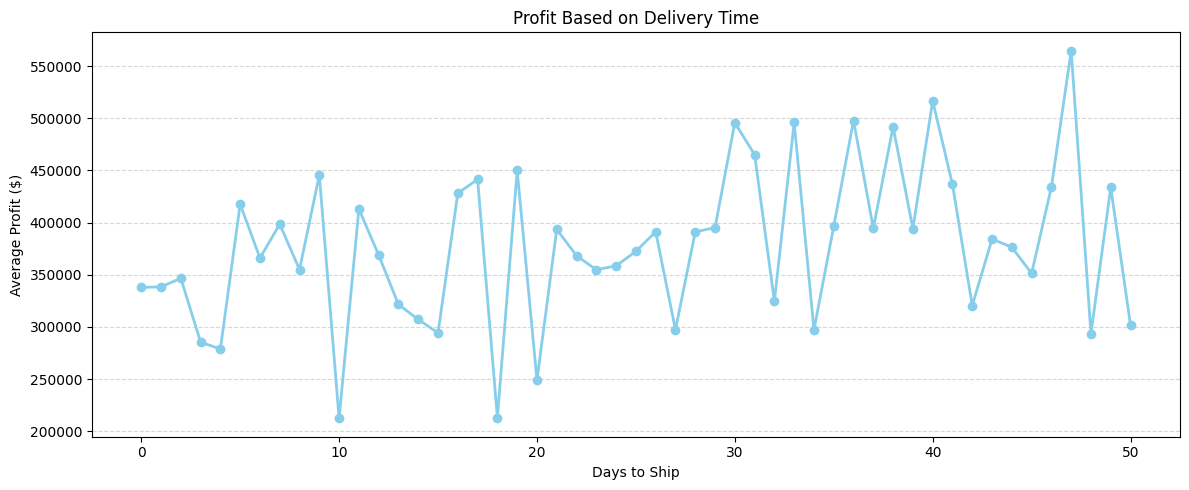

Correlation coefficient: 0.060695
A correlation of 0.06 proves that there is no relationship between profit and delivery time.


In [ ]:
#Profit based on Delivery Time
check_pr = round(merged_df.groupby('processing_time')['profit'].mean().sort_index(), 0)


plt.figure(figsize=(12, 5))
plt.plot(check_pr.index, check_pr.values, color='skyblue', marker='o', linewidth=2) 
plt.title('Profit Based on Delivery Time')
plt.xlabel('Days to Ship')
plt.ylabel('Average Profit ($)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

correlation = merged_df['processing_time'].corr(merged_df['profit'])
print(f"Correlation coefficient: {correlation:.6f}")
print("A correlation of 0.06 proves that there is no relationship between profit and delivery time.")

**Conclusions:**

* Fulfillment Speed Has No Impact on Revenue or Profit: Our data reveals that shipping delays carry absolutely zero financial penalty.
* A deeper look at our inventory operations shows that the warehouse does not handle all items equally.Personal Care products move through the system the fastest, clearing the facility in a sharp 20-day average. Conversely, categories like Baby Food, Cereal, and Office Supplies face noticeable physical handling friction, lingering in the warehouse for a full week longer.
* Order Priority System Failure.  "Critical" and "High" priority shipments are languishing in processing lines just as long as standard "Low" priority orders. While this isn't hurting current margins, it poses a severe threat to client retention and contractual trust.
* Europe serves as a primary operational engine, processing a massive volume of orders. Asia runs on a nearly identical timeline, maintaining stable, reliable turnaround speeds across its current volume footprint.

 Strategic Action Items:

1. Veto any high-cost warehouse acceleration projects or premium shipping upgrades. Because shipping speed does not drive profitability, these capital expenditures will result in a zero financial return
2. Implement operational audits within warehouse processes to ensure that “Critical” and “High” priority orders are physically expedited ahead of standard shipments
3. Optimize workflows for Baby Food, Cereal, and Office Supplies to  align their processing timelines more closely with the 20-day benchmark achieved by Personal Care


### Product & Category Performance

In [ ]:

# Top Products by Orders / Sales / Revenue / Profit 
global_portfolio = merged_df.groupby('item_type').agg(
    total_orders=('order_id', 'count'),
    total_units_sold=('units_sold', 'sum'),
    total_revenue=('revenue', 'sum'),
    total_profit=('profit', 'sum')
).sort_values(by='total_profit', ascending=False)

print("=== GLOBAL PRODUCT PORTFOLIO LEADERBOARD ===")
display(global_portfolio.style.format({
    'total_orders': "{:,} Orders",
    'total_units_sold': "{:,} Units",
    'total_revenue': "${:,.2f}",
    'total_profit': "${:,.2f}"
}))

=== GLOBAL PRODUCT PORTFOLIO LEADERBOARD ===


,total_orders,total_units_sold,total_revenue,total_profit
item_type,,,,
Cosmetics,108 Orders,"506,188.0 Units","$221,305,393.60","$88,010,907.56"
Office Supplies,113 Orders,"581,481.0 Units","$378,666,242.01","$73,411,976.25"
Household,91 Orders,"417,308.0 Units","$278,874,417.16","$69,160,454.84"
Baby Food,105 Orders,"524,265.0 Units","$133,834,369.20","$50,256,042.90"
Clothes,102 Orders,"579,313.0 Units","$63,307,324.64","$42,544,746.72"
Cereal,101 Orders,"460,266.0 Units","$94,676,716.20","$40,774,964.94"
Vegetables,105 Orders,"532,510.0 Units","$82,038,490.60","$33,617,356.30"
Meat,102 Orders,"477,233.0 Units","$201,339,830.37","$27,297,727.60"
Snacks,95 Orders,"453,621.0 Units","$69,213,492.18","$25,012,661.94"


=== MASTER SALES CHANNEL DASHBOARD ===


,total_orders,total_units_sold,total_revenue,total_profit
sales_channel,,,,
Offline,621,"3,113,412.0","$810,030,465.24","$238,511,327.41"
Online,625,"3,058,259.0","$788,953,296.02","$235,197,707.65"


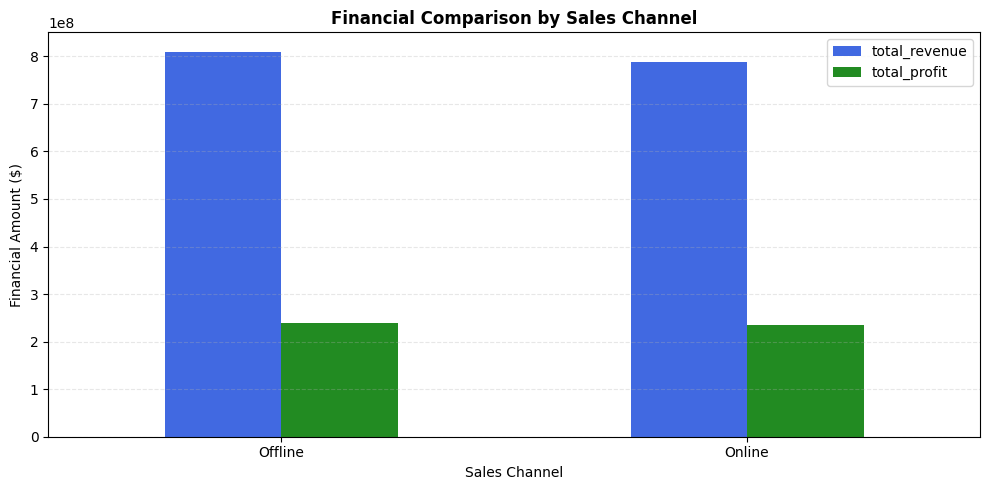


=== TOP PRODUCT BY CHANNEL ===


,item_type,units_sold
sales_channel,,
Offline,Office Supplies,332099.0
Online,Beverages,300730.0


In [ ]:
#Comparison of characteristics by Channels 

merged_df['sales_channel'] = merged_df['sales_channel'].str.capitalize()

channel_dashboard = merged_df.groupby('sales_channel').agg(
    total_orders=('order_id', 'count'),
    total_units_sold=('units_sold', 'sum'),
    total_revenue=('revenue', 'sum'),
    total_profit=('profit', 'sum')
)

print("=== MASTER SALES CHANNEL DASHBOARD ===")
display(channel_dashboard.style.format({
    'total_orders': '{:,}',
    'total_units_sold': '{:,}',
    'total_revenue': '${:,.2f}',
    'total_profit': '${:,.2f}'
}))

channel_dashboard[['total_revenue', 'total_profit']].plot(
    kind='bar', 
    figsize=(10, 5), 
    color=['royalblue', 'forestgreen']
)

plt.title('Financial Comparison by Sales Channel', fontsize=12, fontweight='bold')
plt.ylabel('Financial Amount ($)')
plt.xlabel('Sales Channel')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Finding the Most Popular Product Category per Channel
popular_products = merged_df.groupby(['sales_channel', 'item_type'])['units_sold'].sum().reset_index()
top_products = popular_products.sort_values('units_sold', ascending=False).groupby('sales_channel').head(1)

print("\n=== TOP PRODUCT BY CHANNEL ===")
display(top_products.set_index('sales_channel'))

 Cosmetics is the undisputed profit engine of the enterprise. Despite generating fewer total orders (108) and moving fewer physical units (506K) than categories like Office Supplies or Beverages, it yields $88.01M in net profit from $221.31M in revenue—boasting a staggering profit margin of roughly 40%.

 Office Supplies acts as the largest revenue driver ($378.67M), and second-highest profit driver ($73.41M)

The Margin Traps: Conversely, categories like Beverages and Fruits move tremendous physical volume (577K and 531K units respectively) but yield very small profits ($9.05M and $1.28M). These lines serve as essential customer hooks or baseline commodities but contribute very little to corporate wealth expansion.

 The Online vs. Offline Operational Equilibrium
 The business split between Offline and Online is almost an exact 50/50 split

### Seasonalities Analysis 

=== SUMMARY: Units Sold by Day of Week ===


,Total Units Sold
day_of_week,
Monday,"933,677"
Tuesday,"833,975"
Wednesday,"839,870"
Thursday,"818,022"
Friday,"787,802"
Saturday,"970,549"
Sunday,"987,776"


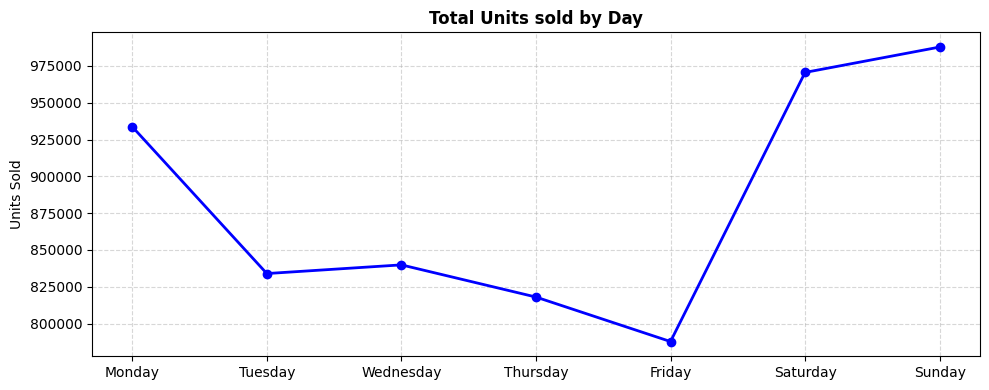

In [134]:
#Sales through weekdays Analysis 
merged_df['day_of_week'] = merged_df['order_date'].dt.day_name()
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

weekly_sales = merged_df.groupby('day_of_week')['units_sold'].sum().reindex(days_order)

print("=== SUMMARY: Units Sold by Day of Week ===")

display(weekly_sales.to_frame(name='Total Units Sold').style.format("{:,.0f}"))

plt.figure(figsize=(10, 4))
plt.plot(weekly_sales.index, weekly_sales.values, marker='o', linestyle='-', color='b', linewidth=2)
plt.title('Total Units sold by Day', fontsize=12, fontweight='bold')
plt.ylabel('Units Sold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


=== SUMMARY: Macro Units Sold by Season ===


,Total Units Sold
season,
Winter,"1,590,564"
Spring,"1,628,300"
Summer,"1,527,256"
Autumn,"1,425,551"


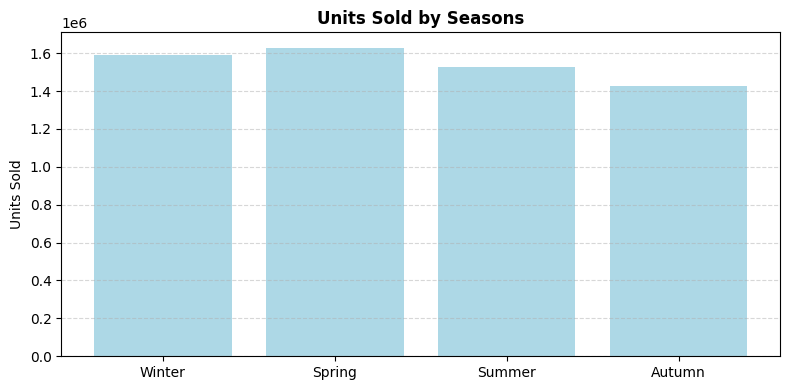

In [135]:
#Sales Volume by Seasons
def get_season(month):
    if month in [12, 1, 2]: return 'Winter'
    elif month in [3, 4, 5]: return 'Spring'
    elif month in [6, 7, 8]: return 'Summer'
    else: return 'Autumn'

merged_df['month_num'] = merged_df['order_date'].dt.month
merged_df['season'] = merged_df['month_num'].apply(get_season)

seasonal_sales = merged_df.groupby('season')['units_sold'].sum().reindex(['Winter', 'Spring', 'Summer', 'Autumn'])

print("\n=== SUMMARY: Macro Units Sold by Season ===")
display(seasonal_sales.to_frame(name='Total Units Sold').style.format("{:,.0f}"))


plt.figure(figsize=(8, 4))
plt.bar(seasonal_sales.index, seasonal_sales.values, color='lightblue')
plt.title('Units Sold by Seasons', fontsize=12, fontweight='bold')
plt.ylabel('Units Sold')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

=== SUMMARY: Units Sold by Month ===


,Total Units Sold
month_name,
January,"594,625"
February,"499,524"
March,"635,482"
April,"482,948"
May,"509,870"
June,"555,833"
July,"563,203"
August,"408,220"
September,"472,398"


C:\Users\Asus\AppData\Local\Temp\ipykernel_22488\501156634.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in current_values])


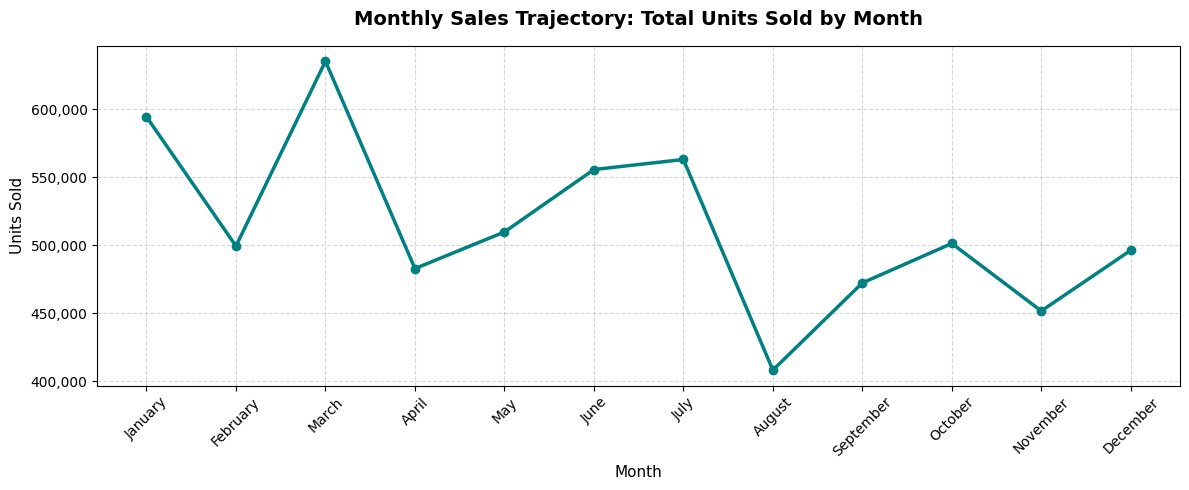

In [137]:
#Units Sold by Month
merged_df['month_num'] = merged_df['order_date'].dt.month
merged_df['month_name'] = merged_df['order_date'].dt.month_name()

# Defining order for months
months_order = [
    'January', 'February', 'March', 'April', 'May', 'June', 
    'July', 'August', 'September', 'October', 'November', 'December'
]

# Aggregating Units Sold by Month
monthly_sales = merged_df.groupby('month_name')['units_sold'].sum().reindex(months_order)

print("=== SUMMARY: Units Sold by Month ===")
display(monthly_sales.to_frame(name='Total Units Sold').style.format("{:,.0f}"))

plt.figure(figsize=(12, 5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', linestyle='-', color='teal', linewidth=2.5)


plt.title('Monthly Sales Trajectory: Total Units Sold by Month', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Month', fontsize=11)
plt.ylabel('Units Sold', fontsize=11)
plt.xticks(rotation=45)  # Rotates month names for better readability
plt.grid(True, linestyle='--', alpha=0.5)

current_values = plt.gca().get_yticks()
plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in current_values])

plt.tight_layout()
plt.show()

 Demand heavily peaks over the weekend, led by Sunday (987,776 units) and Saturday (970,549 units), with strong residual momentum carrying into Monday (933,677 units). Sales bottom out on Friday (787,802 units), representing a ~20% drop from the Sunday peak.

 Consumers heavily favor the weekend and the very start of the workweek to make purchases. Marketing pushes, restocks, and promotional events should be timed to hit between Saturday morning and Monday afternoon to ride this high-intent wave.


Breaking the data down by month reveals localized surges and drops:

 March is the highest-performing month of the year (635,482 units), followed closely by January (594,625 units) while August experiences a massive drop (408,220 units), marking a 35.7% decrease compared to March.

 There is a notable mini-surge in mid-summer (June at 555,833 units and July at 563,203 units) before the August crash.

 Surprisingly, Q4 (October through December) remains highly stable and average, hovering around the 450k–500k mark, showing no massive holiday spike.


When aggregated into macro seasons, 
Spring (1,628,300 units) is the top-performing season, heavily carried by the massive volume in March.

Winter (1,590,564 units) takes a close second place, driven largely by high sustained volume in January and a stable December.

Autumn (1,425,551 units) is the weakest season overall, dragged down by a slower September and November.